# Train PhenoFlex-style cherry bloom models

This notebook builds a compact synthetic cherry bloom dataset from deterministic
hourly weather, fits PhenoFlex-style models with `phenologyFitter`, and compares
observed and predicted bloom dates. The optimization is intentionally small so the
notebook stays useful as a documentation example and as a smoke test.

The data are synthetic: bloom dates are generated from a plausible PhenoFlex-GDH
parameter set with small deterministic year-to-year observation offsets.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from chillPy import (
    PhenoFlex_GDHwrapper,
    PhenoFlex_fixedDynModelwrapper,
    genSeasonList,
    phenologyFitter,
    stack_hourly_temps,
)

DATA = Path("./data")
weather = pd.read_csv(DATA / "synthetic_daily_weather.csv")
hourly = stack_hourly_temps(weather, latitude=42.0)["hourtemps"]
years = list(range(2016, 2023))
season_list = genSeasonList(hourly, mrange=(8, 6), years=years)

pd.DataFrame(
    {
        "Year": years,
        "records": [len(season) for season in season_list],
        "first_jday": [season["JDay"].iloc[0] for season in season_list],
        "last_jday": [season["JDay"].iloc[-1] for season in season_list],
    }
)

,Year,records,first_jday,last_jday
0,2016,8040,213.0,182.0
1,2017,8016,214.0,181.0
2,2018,8016,213.0,181.0
3,2019,8016,213.0,181.0
4,2020,8040,213.0,182.0
5,2021,8016,214.0,181.0
6,2022,8016,213.0,181.0


Generate synthetic cherry bloom dates from a PhenoFlex-GDH parameter set. The
deterministic offsets mimic observation noise and cultivar/site effects without
hiding the known data-generating process.

In [2]:
true_phenoflex_gdh = [
    28.0,       # yc: chill requirement
    75.0,       # zc: forcing requirement
    0.55,       # s1: chill/heat interaction
    25.0,       # Tu: optimum forcing temperature
    3372.8,     # E0
    9900.3,     # E1
    6319.5,     # A0
    5.939917e13,# A1
    4.0,        # Tf
    36.0,       # Tc
    4.0,        # Tb
    1.6,        # slope
]

latent_bloom = np.array(
    [PhenoFlex_GDHwrapper(season, true_phenoflex_gdh) for season in season_list]
)
observation_offsets = np.array([1.5, -2.0, 0.5, 1.0, -1.0, 2.0, -0.5])
bloom = pd.DataFrame(
    {
        "Year": years,
        "cultivar": "Synthetic Bing cherry",
        "latent_model_jday": latent_bloom.round(1),
        "observed_bloom_jday": np.round(latent_bloom + observation_offsets, 1),
    }
)
bloom

,Year,cultivar,latent_model_jday,observed_bloom_jday
0,2016,Synthetic Bing cherry,75.3,76.8
1,2017,Synthetic Bing cherry,74.1,72.1
2,2018,Synthetic Bing cherry,73.3,73.8
3,2019,Synthetic Bing cherry,73.1,74.1
4,2020,Synthetic Bing cherry,72.4,71.4
5,2021,Synthetic Bing cherry,72.0,74.0
6,2022,Synthetic Bing cherry,70.2,69.7


Fit a PhenoFlex-GDH model. To keep this small and identifiable, only the chill and
heat requirements are estimated; the temperature-response constants are fixed at
literature-like values.

In [3]:
phenoflex_gdh_fit = phenologyFitter(
    par_guess=[25.0, 70.0, 0.55, 25.0, 3372.8, 9900.3, 6319.5, 5.939917e13, 4.0, 36.0, 4.0, 1.6],
    lower=[15.0, 50.0, 0.55, 25.0, 3372.8, 9900.3, 6319.5, 5.939917e13, 4.0, 36.0, 4.0, 1.6],
    upper=[40.0, 95.0, 0.55, 25.0, 3372.8, 9900.3, 6319.5, 5.939917e13, 4.0, 36.0, 4.0, 1.6],
    bloom_jdays=bloom["observed_bloom_jday"],
    season_list=season_list,
    modelfn=PhenoFlex_GDHwrapper,
    control={"maxit": 25, "tol": 1e-3},
)

phenoflex_gdh_fit["residuals"].assign(Year=years)

,Season,observed,predicted,residual,Year
0,1,76.8,76.000000,0.800000,2016
1,2,72.1,74.208333,-2.108333,2017
2,3,73.8,74.125000,-0.325000,2018
3,4,74.1,73.500000,0.600000,2019
4,5,71.4,73.166667,-1.766667,2020
5,6,74.0,72.250000,1.750000,2021
6,7,69.7,71.000000,-1.300000,2022


Fit a simpler PhenoFlex-style fixed dynamic model against the same observations.

In [4]:
fixed_dynamic_fit = phenologyFitter(
    par_guess=[25.0, 70.0, 0.55, 25.0, 36.0, 4.0],
    lower=[15.0, 50.0, 0.55, 25.0, 36.0, 4.0],
    upper=[40.0, 95.0, 0.55, 25.0, 36.0, 4.0],
    bloom_jdays=bloom["observed_bloom_jday"],
    season_list=season_list,
    modelfn=PhenoFlex_fixedDynModelwrapper,
    control={"maxit": 25, "tol": 1e-3},
)

fixed_dynamic_fit["residuals"].assign(Year=years)

,Season,observed,predicted,residual,Year
0,1,76.8,75.125000,1.675000,2016
1,2,72.1,74.166667,-2.066667,2017
2,3,73.8,73.583333,0.216667,2018
3,4,74.1,73.000000,1.100000,2019
4,5,71.4,72.291667,-0.891667,2020
5,6,74.0,70.708333,3.291667,2021
6,7,69.7,70.083333,-0.383333,2022


Compare model skill and collect the fitted parameter values.

In [5]:
def score_row(name, fit):
    return {
        "model": name,
        "rmse_days": fit["rmse"],
        "objective": fit["objective"],
        "parameters": np.array2string(fit["par"], precision=3, suppress_small=False),
    }

scores = pd.DataFrame(
    [
        score_row("PhenoFlex GDH", phenoflex_gdh_fit),
        score_row("Fixed dynamic PhenoFlex", fixed_dynamic_fit),
    ]
)
scores

,model,rmse_days,objective,parameters
0,PhenoFlex GDH,1.384831,13.424306,[4.000e+01 7.281e+01 5.500e-01 2.500e+01 3.373...
1,Fixed dynamic PhenoFlex,1.694983,20.110764,[35.938 92.5 0.55 25. 36. 4. ]


In [6]:
comparison = bloom[["Year", "observed_bloom_jday"]].copy()
comparison["PhenoFlex GDH"] = phenoflex_gdh_fit["pbloomJDays"]
comparison["Fixed dynamic PhenoFlex"] = fixed_dynamic_fit["pbloomJDays"]
comparison

,Year,observed_bloom_jday,PhenoFlex GDH,Fixed dynamic PhenoFlex
0,2016,76.8,76.000000,75.125000
1,2017,72.1,74.208333,74.166667
2,2018,73.8,74.125000,73.583333
3,2019,74.1,73.500000,73.000000
4,2020,71.4,73.166667,72.291667
5,2021,74.0,72.250000,70.708333
6,2022,69.7,71.000000,70.083333


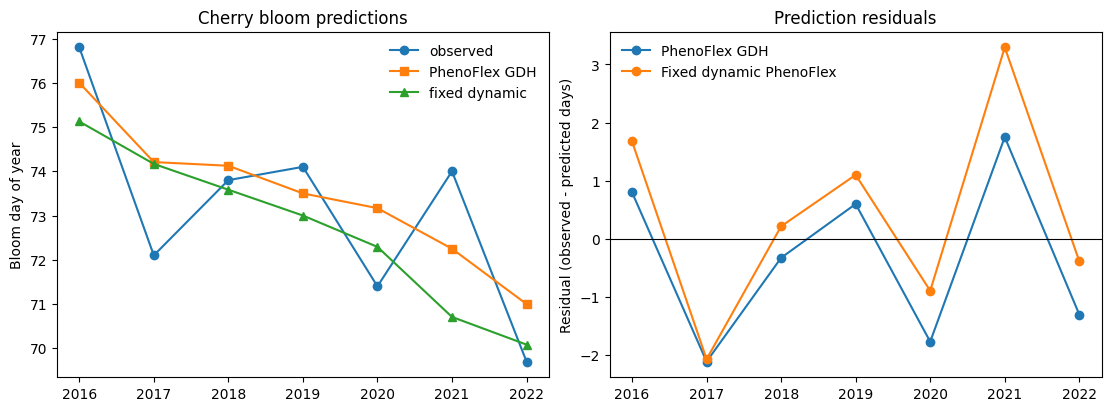

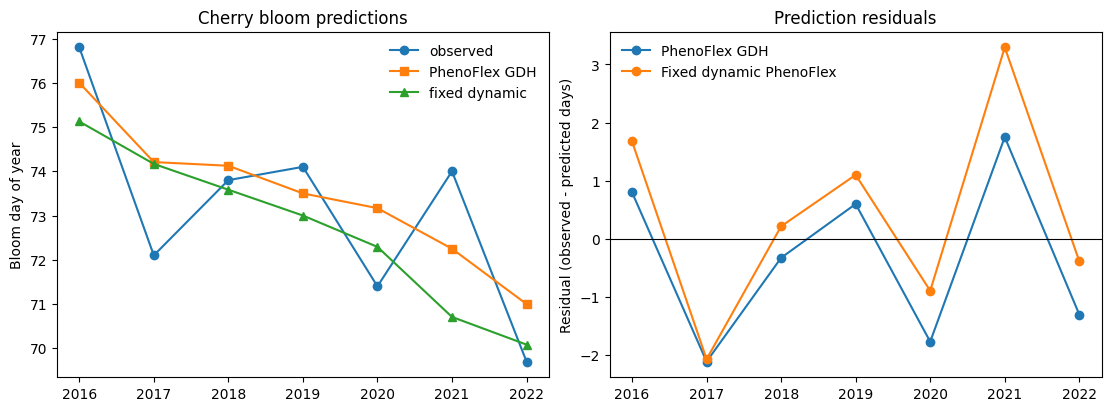

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(comparison["Year"], comparison["observed_bloom_jday"], marker="o", label="observed")
axes[0].plot(comparison["Year"], comparison["PhenoFlex GDH"], marker="s", label="PhenoFlex GDH")
axes[0].plot(
    comparison["Year"],
    comparison["Fixed dynamic PhenoFlex"],
    marker="^",
    label="fixed dynamic",
)
axes[0].set_ylabel("Bloom day of year")
axes[0].set_title("Cherry bloom predictions")
axes[0].legend(frameon=False)

for model_name in ["PhenoFlex GDH", "Fixed dynamic PhenoFlex"]:
    residual = comparison["observed_bloom_jday"] - comparison[model_name]
    axes[1].plot(comparison["Year"], residual, marker="o", label=model_name)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Residual (observed - predicted days)")
axes[1].set_title("Prediction residuals")
axes[1].legend(frameon=False)

fig